In [1]:
from google.colab import files
uploaded = files.upload()


Saving HousePrices.csv to HousePrices.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("HousePrices.csv")
print("Shape:", df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [6]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

# Fill missing values with the median of each column
numeric_df = numeric_df.fillna(numeric_df.median())

print("Selected features shape:", numeric_df.shape)
numeric_df.head()

Selected features shape: (1460, 38)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000


In [7]:
numeric_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,69.863699,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,22.027677,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


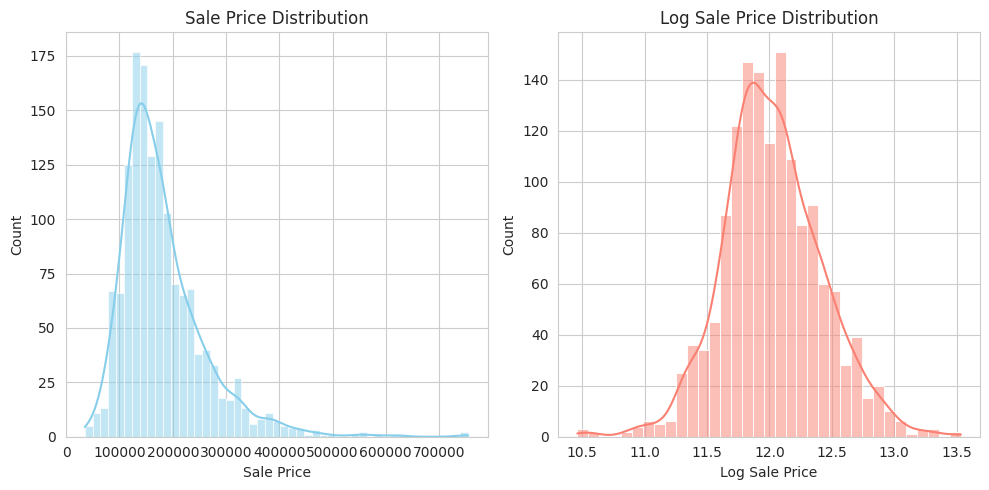

In [8]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(df["SalePrice"], kde=True, color="skyblue")
plt.title("Sale Price Distribution")
plt.xlabel("Sale Price")

plt.subplot(1,2,2)
sns.histplot(np.log1p(df["SalePrice"]), kde=True, color="salmon")
plt.title("Log Sale Price Distribution")
plt.xlabel("Log Sale Price")

plt.tight_layout()
plt.show()

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
GarageYrBlt     0.466754
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


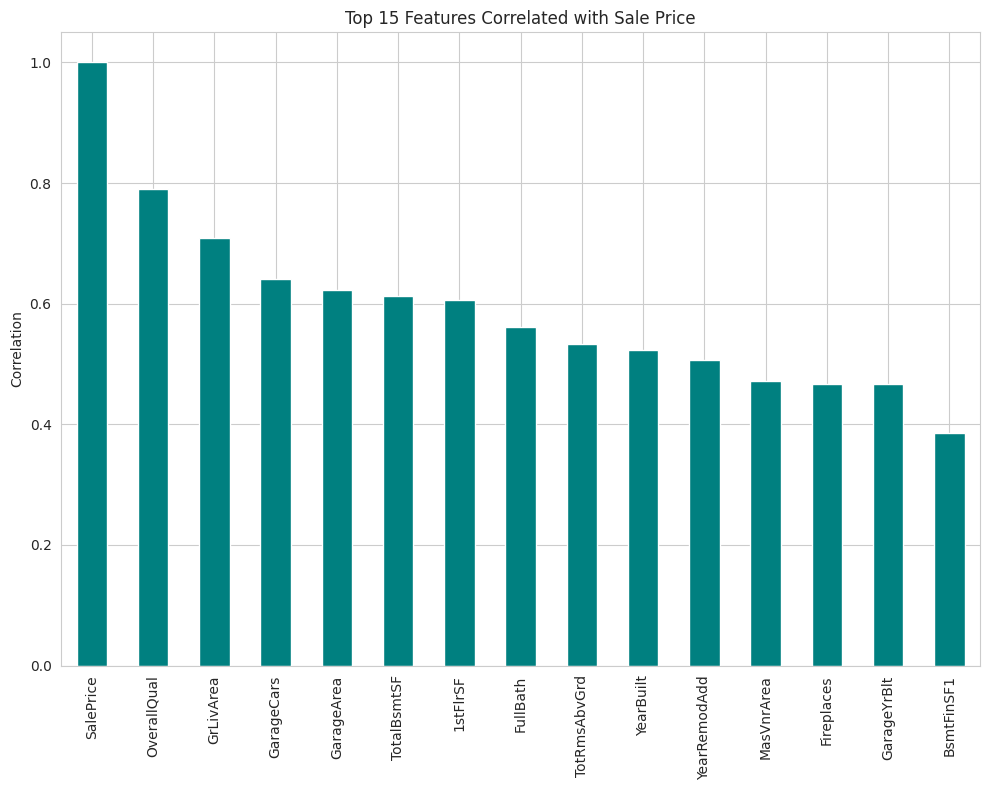

In [9]:
correlation = numeric_df.corr()["SalePrice"].sort_values(ascending=False)
print(correlation.head(15))

plt.figure(figsize=(10,8))
correlation.head(15).plot(kind="bar", color="teal")
plt.title("Top 15 Features Correlated with Sale Price")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

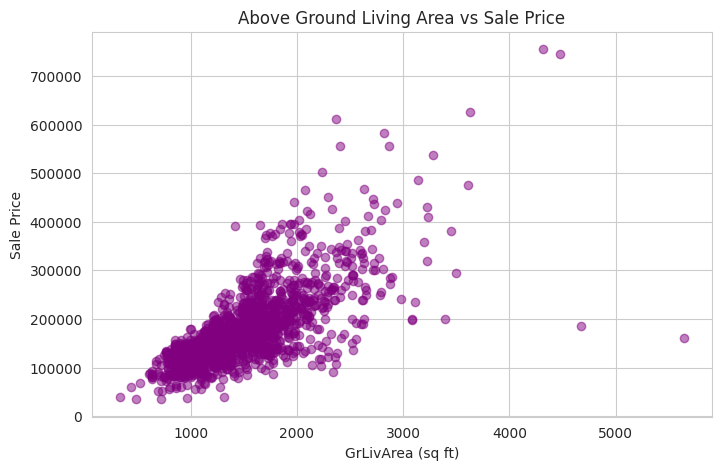

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df["GrLivArea"], df["SalePrice"], alpha=0.5, color="purple")
plt.title("Above Ground Living Area vs Sale Price")
plt.xlabel("GrLivArea (sq ft)")
plt.ylabel("Sale Price")
plt.show()

In [12]:
# Define features (everything except SalePrice) and target (SalePrice)
X = numeric_df.drop("SalePrice", axis=1)
y = np.log1p(numeric_df["SalePrice"])  # log transform the target

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1168, 37)
Testing set size: (292, 37)


In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Number of features used:", X_train.shape[1])

Model trained successfully!
Number of features used: 37


In [15]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error (RMSE):", round(rmse, 4))
print("R-squared Score (R²):", round(r2, 4))
print("\nInterpretation:")
print(f"The model explains {round(r2*100, 2)}% of the variance in house prices.")

Root Mean Squared Error (RMSE): 0.1519
R-squared Score (R²): 0.8764

Interpretation:
The model explains 87.64% of the variance in house prices.


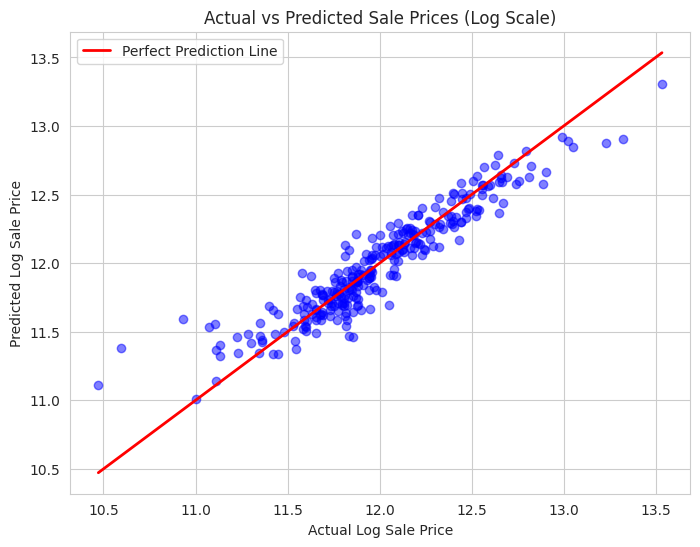

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linewidth=2, label="Perfect Prediction Line")
plt.title("Actual vs Predicted Sale Prices (Log Scale)")
plt.xlabel("Actual Log Sale Price")
plt.ylabel("Predicted Log Sale Price")
plt.legend()
plt.show()

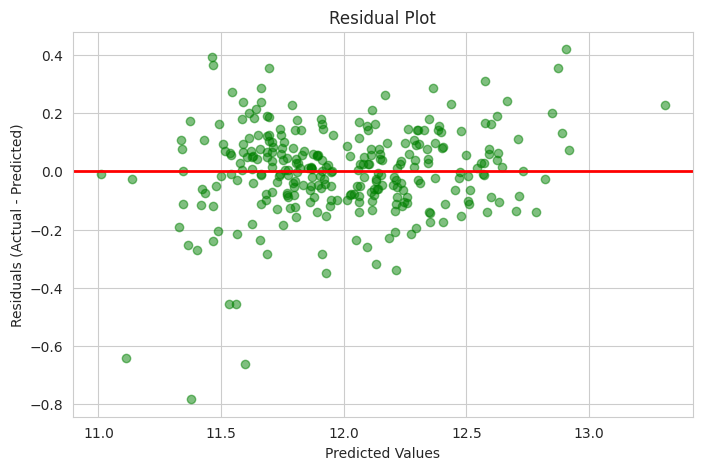

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5, color="green")
plt.axhline(y=0, color="red", linewidth=2)
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()

## Insights and Recommendations

1. The dataset contained 1,460 house records with 81 features. Missing values were handled by filling with column medians, ensuring no data was lost during analysis.

2. The most correlated feature with sale price was OverallQual (overall quality rating), followed by GrLivArea (above ground living area), GarageCars (garage capacity), and GarageArea. This confirms that house quality and size are the strongest drivers of price.

3. Sale prices were right-skewed (a few very expensive houses stretched the distribution), so a log transformation was applied to normalize the target variable before training.

4. The Linear Regression model achieved an R² score of 0.87 on the test set,
meaning it explains 87% of the variance in house sale prices.

5. The predicted vs actual scatter plot showed that predictions cluster closely around the perfect prediction line, confirming the model performs well.

6. The residual plot showed errors scattered randomly around zero with no clear pattern, which is a good sign that the model is unbiased.

7. To improve the model further, future work could include feature engineering, handling categorical variables, and trying more advanced models like Random Forest or Gradient Boosting.
